<a href="https://colab.research.google.com/github/Rudrajit12/Churn-Analysis-and-Customer-Intelligence/blob/main/churn_analysis_detailed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Analysis & Customer Intelligence — Detailed Analysis

**Project type:** Customer churn / retention analytics  
**Business context:** OTT / subscription business  
**Primary tools:** SQLite, SQL, Python, pandas, NumPy, Matplotlib, Seaborn

## Objective

Build a portfolio-grade, end-to-end Customer Churn Intelligence solution for an OTT subscription business using customer, subscription, and support data from the provided customer_churn.db.

The project aims to transform raw relational data into actionable retention intelligence by answering four key business questions:

- Who is churning or currently represents the highest retention risk?
- Why are customers churning, and which customer, subscription, acquisition, geographic, and support factors are associated with churn?
- When does churn occur, and which stages of the customer lifecycle represent potential danger zones?
- What should the business do to reduce churn, protect recurring revenue, and prioritize retention efforts based on customer risk and value?

The analysis will cover the complete workflow from SQL data extraction and data-quality validation → data cleaning → feature engineering → exploratory analysis → customer segmentation → churn-risk analysis → revenue/CLTV impact → actionable business recommendations.

## Reference-project scope

The supplied report describes three relational tables:

1. `db_customer` — demographic/customer attributes
2. `db_subscription` — subscription, contract, billing, CLTV and churn-score attributes
3. `db_support` — complaints, escalations and CSAT

The report defines core KPIs including churn rate, retention rate, churn by plan/state, ARPU, average tenure, revenue at risk, escalation rate, average complaints per customer, and escalation-vs-churn analysis.

**Source note:** The supplied reference report is the basis for the project framing and KPI definitions; all numerical results below are calculated from the provided database.

In [10]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

DB_PATH = Path("/content/drive/My Drive/EDA Projects/Churn Analysis & Customer Intelligence/customer_churn.db")

print("Database:", DB_PATH.resolve())
print("Exists:", DB_PATH.exists())

Database: /content/drive/My Drive/EDA Projects/Churn Analysis & Customer Intelligence/customer_churn.db
Exists: True


# 1. Database Connection & Data Extraction

We first connect to SQLite, inspect the available tables, then import each table into pandas.

A key principle from the reference workflow is to **inspect the database structure before analysis** rather than assuming table names or schemas.

In [11]:
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# List contents of the directory where the database is expected to be
db_directory = '/content/drive/My Drive/EDA Projects/Churn Analysis & Customer Intelligence/'
print(f"Listing contents of: {db_directory}")
if os.path.exists(db_directory):
    for item in os.listdir(db_directory):
        print(item)
else:
    print(f"Directory not found: {db_directory}")

Listing contents of: /content/drive/My Drive/EDA Projects/Churn Analysis & Customer Intelligence/
customer_churn_data_raw.xlsx
customer_churn.db
Data Analytics Project -Churn Analysis Report.pdf
exported_churn_analysis_detailed.csv
churn_analysis_detailed.ipynb


In [12]:
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

tables

,name
0,db_customer
1,db_subscription
2,db_support


In [13]:
# Inspect schema and row counts for every table
schema_summary = []

for table_name in tables["name"]:
    info = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)
    row_count = pd.read_sql_query(f"SELECT COUNT(*) AS n_rows FROM {table_name};", conn)["n_rows"].iloc[0]

    for _, row in info.iterrows():
        schema_summary.append({
            "table": table_name,
            "column": row["name"],
            "sqlite_type": row["type"],
            "not_null": row["notnull"],
            "primary_key": row["pk"],
            "row_count": row_count
        })

schema_df = pd.DataFrame(schema_summary)
display(schema_df)

,table,column,sqlite_type,not_null,primary_key,row_count
0,db_customer,customerid,TEXT,0,0,21
1,db_customer,name,TEXT,0,0,21
2,db_customer,country,TEXT,0,0,21
3,db_customer,state,TEXT,0,0,21
4,db_customer,gender,TEXT,0,0,21
5,db_customer,dob,TIMESTAMP,0,0,21
6,db_customer,interests,TEXT,0,0,21
7,db_customer,pincode,REAL,0,0,21
8,db_subscription,customerid,TEXT,0,0,21
9,db_subscription,subscription_start_date,TEXT,0,0,21


In [14]:
# Import each source table
df_db_customer = pd.read_sql_query("SELECT * FROM db_customer;", conn)
df_db_subscription = pd.read_sql_query("SELECT * FROM db_subscription;", conn)
df_db_support = pd.read_sql_query("SELECT * FROM db_support;", conn)

print("Customer:", df_db_customer.shape)
print("Subscription:", df_db_subscription.shape)
print("Support:", df_db_support.shape)

conn.close()

Customer: (21, 8)
Subscription: (21, 11)
Support: (9, 6)


## Source-table grain

Before joining tables, establish the grain:

- `db_customer`: expected **one row per customer**
- `db_subscription`: expected **one row per customer/subscription record**
- `db_support`: **one or more rows per customer** because a customer can make multiple complaints

That last point is important. A direct one-to-many merge would duplicate subscription rows and distort customer-level KPIs. The reference notebook addresses this by counting support records and retaining one latest support row; here we make that logic explicit with a customer-level support aggregation.

In [15]:
# Cardinality checks
cardinality = pd.DataFrame({
    "table": ["db_customer", "db_subscription", "db_support"],
    "rows": [
        len(df_db_customer),
        len(df_db_subscription),
        len(df_db_support)
    ],
    "unique_customers": [
        df_db_customer["customerid"].nunique(),
        df_db_subscription["customerid"].nunique(),
        df_db_support["customerid"].nunique()
    ]
})

cardinality

,table,rows,unique_customers
0,db_customer,21,21
1,db_subscription,21,21
2,db_support,9,7


# 2. Data Quality Audit

We check:
- duplicate customer IDs,
- missing values,
- duplicate support events,
- referential integrity,
- date parsing issues,
- categorical consistency,
- impossible/invalid values.

The objective is not to remove data simply because it is missing. Each treatment is documented so that the cleaned dataset remains traceable to the source.

In [16]:
def missing_summary(df, name):
    out = df.isna().sum().to_frame("missing_count")
    out["missing_pct"] = out["missing_count"] / len(df) * 100
    out.insert(0, "table", name)
    return out[out["missing_count"] > 0].sort_values("missing_count", ascending=False)

display(missing_summary(df_db_customer, "db_customer"))
display(missing_summary(df_db_subscription, "db_subscription"))
display(missing_summary(df_db_support, "db_support"))

,table,missing_count,missing_pct
pincode,db_customer,21,100.00
interests,db_customer,17,80.95
country,db_customer,3,14.29


,table,missing_count,missing_pct
cancellation_date,db_subscription,15,71.43
cancellation_reason,db_subscription,15,71.43


,table,missing_count,missing_pct
col_1,db_support,9,100.00
comment,db_support,5,55.56


In [17]:
# Duplicate and uniqueness checks
quality_checks = {
    "customer_duplicate_ids": df_db_customer["customerid"].duplicated().sum(),
    "subscription_duplicate_ids": df_db_subscription["customerid"].duplicated().sum(),
    "support_duplicate_rows": df_db_support.duplicated().sum(),
    "support_customers_with_multiple_records": (df_db_support["customerid"].value_counts() > 1).sum(),
}

pd.Series(quality_checks, name="count").to_frame()

,count
customer_duplicate_ids,0
subscription_duplicate_ids,0
support_duplicate_rows,0
support_customers_with_multiple_records,2


In [18]:
# Referential integrity checks
customer_ids = set(df_db_customer["customerid"])
subscription_ids = set(df_db_subscription["customerid"])
support_ids = set(df_db_support["customerid"])

integrity = pd.Series({
    "subscription IDs missing from customer table": len(subscription_ids - customer_ids),
    "support IDs missing from customer table": len(support_ids - customer_ids),
    "customers without subscription record": len(customer_ids - subscription_ids),
})

integrity.to_frame("count")

,count
subscription IDs missing from customer table,0
support IDs missing from customer table,0
customers without subscription record,0


In [19]:
# Source-level categorical inspection
for col in ["gender"]:
    print(f"{col}:", sorted(df_db_customer[col].dropna().astype(str).unique()))

for col in ["subscription_type", "plan_type", "contract_type"]:
    print(f"{col}:", sorted(df_db_subscription[col].dropna().astype(str).unique()))

print("Escalations:", sorted(df_db_support["escalations"].dropna().astype(str).unique()))

gender: ['Female', 'Male', 'Men', 'Women']
subscription_type: ['Organic', 'Paid', 'Refferal']
plan_type: ['Basic', 'Premium', 'Standard']
contract_type: ['Annual', 'Monthly']
Escalations: ['N', 'Y']


# 3. Data Cleaning

The cleaning steps reproduce the reference notebook while adding a few explicit quality improvements.

### Customer table
- rename `name` → `customer_name`
- drop `interests` and `pincode` because they are not used in this analysis
- convert `dob` to datetime
- standardize `Men` / `Women` to `Male` / `Female`
- fill missing country using the observed state→country mapping

### Subscription table
- convert subscription, renewal and cancellation fields to datetime
- create the binary `churn_flag`

### Support table
- drop unused `col_1` and `comment`
- convert complaint date to datetime
- aggregate all support events to **one row per customer**

In [20]:
# Customer cleaning
customer = df_db_customer.copy()

customer = customer.rename(columns={"name": "customer_name"})
customer = customer.drop(columns=["interests", "pincode"])

customer["dob"] = pd.to_datetime(customer["dob"], errors="coerce")
customer["gender"] = customer["gender"].replace({
    "Men": "Male",
    "Women": "Female"
})

# Fill missing country from the state-country relationship observed in non-null records.
state_country_mapping = (
    customer.dropna(subset=["country"])
    .drop_duplicates("state")
    .set_index("state")["country"]
    .to_dict()
)

customer["country"] = customer["country"].fillna(customer["state"].map(state_country_mapping))

customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [21]:
# Subscription cleaning
subscription = df_db_subscription.copy()

date_cols = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

for col in date_cols:
    subscription[col] = pd.to_datetime(subscription[col], errors="coerce")

# The source contains the spelling "Refferal"; standardize it for analysis.
subscription["subscription_type"] = subscription["subscription_type"].replace({
    "Refferal": "Referral"
})

# Churn definition: cancellation_date is populated.
subscription["churn_flag"] = subscription["cancellation_date"].notna().astype(int)

subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [22]:
# Support cleaning + customer-level aggregation
support = df_db_support.copy()

support = support.drop(columns=["col_1", "comment"])
support["complaint_date"] = pd.to_datetime(support["complaint_date"], errors="coerce")

support["is_escalation"] = (support["escalations"] == "Y").astype(int)

# Sort so "latest" support fields are deterministic.
support = support.sort_values(["customerid", "complaint_date"])

support_agg = (
    support.groupby("customerid")
    .agg(
        complaint_count=("customerid", "size"),
        escalation_count=("is_escalation", "sum"),
        has_escalation=("is_escalation", "max"),
        avg_csat=("csat_score", "mean"),
        latest_complaint_date=("complaint_date", "max")
    )
    .reset_index()
)

latest_support = (
    support.groupby("customerid", as_index=False)
    .tail(1)[["customerid", "escalations", "csat_score"]]
    .rename(columns={
        "escalations": "latest_escalation",
        "csat_score": "latest_csat"
    })
)

support_agg = support_agg.merge(latest_support, on="customerid", how="left")

support_agg.head()

,customerid,complaint_count,escalation_count,has_escalation,avg_csat,latest_complaint_date,latest_escalation,latest_csat
0,0003-MKNFE,2,1,1,35.00,2024-08-28,Y,10
1,0013-EXCHZ,1,1,1,20.00,2024-01-20,Y,20
2,0013-MHZWF,1,0,0,90.00,2025-03-18,N,90
3,0013-SMEOE,1,0,0,30.00,2024-11-01,N,30
4,0017-IUDMW,1,1,1,25.00,2024-04-10,Y,25


# 4. Build the Analysis Dataset

We join the three sources at **customer level**.

The support data is aggregated first so the final dataset remains one row per customer. This prevents a classic one-to-many join problem where customers with multiple complaints would be counted multiple times.

In [23]:
# Join and validate row count
analysis = (
    subscription
    .merge(customer, on="customerid", how="left", validate="one_to_one")
    .merge(support_agg, on="customerid", how="left", validate="one_to_one")
)

# Customers with no support records should have zero complaint/escalation counts.
count_cols = ["complaint_count", "escalation_count", "has_escalation"]
analysis[count_cols] = analysis[count_cols].fillna(0)

analysis["has_escalation"] = analysis["has_escalation"].astype(int)

print("Final analysis shape:", analysis.shape)
print("Unique customers:", analysis["customerid"].nunique())
print("Duplicate customer IDs:", analysis["customerid"].duplicated().sum())

Final analysis shape: (21, 24)
Unique customers: 21
Duplicate customer IDs: 0


In [24]:
# Final dataset preview
analysis.head(10)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_count,escalation_count,has_escalation,avg_csat,latest_complaint_date,latest_escalation,latest_csat
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,0.00,0.00,0,NaN,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2.00,1.00,1,35.00,2024-08-28,Y,10.00
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,0.00,0.00,0,NaN,NaT,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,0.00,0.00,0,NaN,NaT,NaN,NaN
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,1.00,1.00,1,20.00,2024-01-20,Y,20.00
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,1.00,0.00,0,90.00,2025-03-18,N,90.00
6,0013-SMEOE,2021-09-30,Referral,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,1.00,0.00,0,30.00,2024-11-01,N,30.00
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,0.00,0.00,0,NaN,NaT,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,0.00,0.00,0,NaN,NaT,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29,0.00,0.00,0,NaN,NaT,NaN,NaN


In [25]:
# Final null audit
final_missing = (
    analysis.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(analysis) * 100)
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

final_missing

,missing_count,missing_pct
cancellation_date,15,71.43
cancellation_reason,15,71.43
avg_csat,14,66.67
latest_complaint_date,14,66.67
latest_escalation,14,66.67
latest_csat,14,66.67


# 5. Feature Engineering

We create analysis-ready fields:

- `churn_flag`: 1 if cancelled, else 0
- `tenure_days`: days from subscription start to cancellation for churned users; for active users, days from subscription start to a fixed analysis cutoff
- `customer_age`: age at the analysis cutoff
- `cancellation_month`: month in which churn occurred
- `churn_risk`: Low / Medium / High using the source `churn_score`
- support intensity measures from the aggregated support table

### Reproducibility choice

The original reference notebook uses `NOW()` / today's date for active-customer tenure. That makes the number change every time the notebook is run. For a portfolio project, we use a fixed **data cutoff date** equal to the latest date observed in the subscription/support data.

This keeps the analysis reproducible and avoids silently changing the historical result.

In [26]:
# Determine a reproducible cutoff from the source data.
all_relevant_dates = pd.concat([
    subscription["subscription_start_date"],
    subscription["renewal_date"],
    subscription["cancellation_date"],
    support["complaint_date"]
]).dropna()

DATA_CUTOFF_DATE = all_relevant_dates.max().normalize()
DATA_CUTOFF_DATE

Timestamp('2025-12-31 00:00:00')

In [27]:
# Tenure
analysis["tenure_end_date"] = analysis["cancellation_date"].fillna(DATA_CUTOFF_DATE)

analysis["tenure_days"] = (
    analysis["tenure_end_date"] - analysis["subscription_start_date"]
).dt.days

# Age
analysis["customer_age"] = (
    (DATA_CUTOFF_DATE - analysis["dob"]).dt.days / 365.25
).round(1)

# Cancellation month
analysis["cancellation_month"] = analysis["cancellation_date"].dt.to_period("M")

# Churn risk based on supplied churn_score
analysis["churn_risk"] = pd.cut(
    analysis["churn_score"],
    bins=[-np.inf, 49, 69, np.inf],
    labels=["Low", "Medium", "High"]
)

analysis[[
    "customerid", "churn_flag", "tenure_days",
    "customer_age", "churn_score", "churn_risk"
]].head()

,customerid,churn_flag,tenure_days,customer_age,churn_score,churn_risk
0,0002-ORFBO,0,1752,43.70,12,Low
1,0003-MKNFE,1,1501,30.10,91,High
2,0004-TLHLJ,0,1137,47.90,34,Low
3,0011-IGKFF,0,2427,24.30,8,Low
4,0013-EXCHZ,1,419,35.70,88,High


# 6. Core Business KPIs

The reference report defines the main KPIs as:

- **Churn rate** = churned customers / total customers
- **Retention rate** = 1 − churn rate
- **ARPU** = total monthly charges / active customers
- **Average tenure**
- **Revenue at risk** = monthly charges associated with churned / high-risk customers
- **Average complaints per customer**
- **Escalation rate**
- **Escalation → churn relationship**

Because this is a very small dataset, the notebook also distinguishes between **descriptive metrics** and stronger causal/model claims.

In [28]:
total_customers = analysis["customerid"].nunique()
churned_customers = analysis["churn_flag"].sum()
active_customers = total_customers - churned_customers

churn_rate = churned_customers / total_customers * 100
retention_rate = 100 - churn_rate

# The reference defines ARPU using active customers.
active_mrr = analysis.loc[analysis["churn_flag"] == 0, "monthly_charges"].sum()
arpu = active_mrr / active_customers

avg_tenure_days = analysis["tenure_days"].mean()

# Revenue associated with churned customers; use "MRR proxy" rather than assuming accounting treatment.
churned_mrr = analysis.loc[analysis["churn_flag"] == 1, "monthly_charges"].sum()
revenue_at_risk_pct = churned_mrr / analysis["monthly_charges"].sum() * 100

cltv_lost = analysis.loc[analysis["churn_flag"] == 1, "cltv"].sum()
avg_complaints_per_customer = analysis["complaint_count"].sum() / total_customers

support_customers = (analysis["complaint_count"] > 0).sum()
escalated_complaint_events = analysis["escalation_count"].sum()
total_complaints = analysis["complaint_count"].sum()
escalation_rate = escalated_complaint_events / total_complaints * 100

kpis = pd.DataFrame({
    "KPI": [
        "Total customers",
        "Churned customers",
        "Active customers",
        "Churn rate",
        "Retention rate",
        "Active-customer ARPU",
        "Average tenure (days)",
        "Churned-customer monthly charges (MRR proxy)",
        "Churned monthly-charge share",
        "CLTV associated with churned customers",
        "Average complaints per customer",
        "Escalation rate among complaint events"
    ],
    "Value": [
        total_customers,
        churned_customers,
        active_customers,
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        f"{arpu:.2f}",
        f"{avg_tenure_days:.0f}",
        f"{churned_mrr:.2f}",
        f"{revenue_at_risk_pct:.2f}%",
        f"{cltv_lost:.0f}",
        f"{avg_complaints_per_customer:.2f}",
        f"{escalation_rate:.2f}%"
    ]
})

kpis

,KPI,Value
0,Total customers,21
1,Churned customers,6
2,Active customers,15
3,Churn rate,28.57%
4,Retention rate,71.43%
5,Active-customer ARPU,21.46
6,Average tenure (days),1355
7,Churned-customer monthly charges (MRR proxy),73.94
8,Churned monthly-charge share,18.68%
9,CLTV associated with churned customers,2047


### KPI interpretation

The supplied reference report gives a 28.6% churn rate, 71.4% retention rate, ₹18.8 ARPU and 73.94 of monthly charges associated with churn. The churn rate and retention rate reproduce exactly from the database. ARPU differs if we strictly apply the reference formula because the active-customer denominator is used here, while the original notebook calculates the overall mean of `monthly_charges`.

For portfolio-quality analysis, the denominator should be stated explicitly rather than hidden inside the metric name.

In [29]:
# Show both ARPU interpretations so the definition is transparent.
arpu_active_definition = (
    analysis.loc[analysis["churn_flag"] == 0, "monthly_charges"].sum()
    / active_customers
)

arpu_overall_mean = analysis["monthly_charges"].mean()

pd.DataFrame({
    "Definition": [
        "Active-customer ARPU = active monthly charges / active customers",
        "Overall mean monthly_charges (reference notebook calculation)"
    ],
    "Value": [arpu_active_definition, arpu_overall_mean]
})

,Definition,Value
0,Active-customer ARPU = active monthly charges ...,21.46
1,Overall mean monthly_charges (reference notebo...,18.85


# 7. Churn by Contract, Plan & Acquisition Type

These segments answer **who** is leaving.

We report both:
- **churn rate** — risk within the segment
- **customer count / churned count** — scale of the issue

This matters because a 100% churn rate from two customers is not directly comparable with a 25% rate from 100 customers.

In [30]:
def segment_summary(df, group_col):
    return (
        df.groupby(group_col, dropna=False)
        .agg(
            customers=("customerid", "nunique"),
            churned=("churn_flag", "sum"),
            churn_rate=("churn_flag", "mean"),
            monthly_charges=("monthly_charges", "sum"),
            cltv=("cltv", "sum")
        )
        .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
        .drop(columns="churn_rate")
        .sort_values(["churn_rate_pct", "customers"], ascending=[False, False])
    )

contract_summary = segment_summary(analysis, "contract_type")
plan_summary = segment_summary(analysis, "plan_type")
acquisition_summary = segment_summary(analysis, "subscription_type")

print("CONTRACT")
display(contract_summary)

print("PLAN")
display(plan_summary)

print("ACQUISITION TYPE")
display(acquisition_summary)

CONTRACT


,customers,churned,monthly_charges,cltv,churn_rate_pct
contract_type,,,,,
Monthly,9,5,109.91,2777,55.56
Annual,12,1,285.88,14517,8.33


PLAN


,customers,churned,monthly_charges,cltv,churn_rate_pct
plan_type,,,,,
Basic,5,3,52.95,977,60.00
Standard,9,2,123.91,5302,22.22
Premium,7,1,218.93,11015,14.29


ACQUISITION TYPE


,customers,churned,monthly_charges,cltv,churn_rate_pct
subscription_type,,,,,
Referral,6,5,74.94,1524,83.33
Paid,6,1,174.94,7410,16.67
Organic,9,0,145.91,8360,0.00


In [31]:
# Contract churn-rate gap
monthly_rate = contract_summary.loc["Monthly", "churn_rate_pct"]
annual_rate = contract_summary.loc["Annual", "churn_rate_pct"]

contract_rate_gap_pp = monthly_rate - annual_rate
contract_relative_ratio = monthly_rate / annual_rate

pd.DataFrame({
    "Metric": [
        "Monthly churn rate",
        "Annual churn rate",
        "Absolute gap (percentage points)",
        "Monthly / annual churn-rate ratio"
    ],
    "Value": [
        f"{monthly_rate:.2f}%",
        f"{annual_rate:.2f}%",
        f"{contract_rate_gap_pp:.2f} pp",
        f"{contract_relative_ratio:.2f}x"
    ]
})

,Metric,Value
0,Monthly churn rate,55.56%
1,Annual churn rate,8.33%
2,Absolute gap (percentage points),47.22 pp
3,Monthly / annual churn-rate ratio,6.67x


### Key segment findings

- Monthly contracts churn at **55.56%**, compared with **8.33%** for annual contracts.
- The absolute difference is **47.22 percentage points**.
- Basic has the highest plan-level churn rate at **60%**.
- Referral acquisition has an **83.33%** churn rate in this sample, with 5 of 6 referral customers churning.
- Organic has 0% churn in this small sample, while Paid has 16.67%.

These are strong descriptive signals, but the sample contains only 21 customers, so they should be treated as hypotheses for deeper investigation rather than population-level conclusions.

# 8. Geographic Churn Analysis

The reference project specifically asks for churn by state/country.

We show:
- customers,
- churned customers,
- churn rate,
- monthly charges,
- churn-related monthly-charge exposure.

Small segment sizes are displayed explicitly to prevent overinterpretation.

In [32]:
geo_summary = (
    analysis.groupby(["country", "state"], dropna=False)
    .agg(
        customers=("customerid", "nunique"),
        churned=("churn_flag", "sum"),
        churn_rate=("churn_flag", "mean"),
        monthly_charges=("monthly_charges", "sum")
    )
    .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
    .drop(columns="churn_rate")
    .sort_values(["churn_rate_pct", "customers"], ascending=[False, False])
)

geo_summary

customers  churned  monthly_charges  churn_rate_pct
country state                                                             
India   Karnataka              2        2            20.98          100.00
        Meghalaya              3        2            42.97           66.67
        Telangana              2        1            30.98           50.00
        Delhi                  4        1            52.96           25.00
        Maharashtra            3        0            50.97            0.00
        Rajasthan              2        0            36.98            0.00
        Uttar Pradesh          2        0           115.98            0.00
Nepal   Kathmandu              2        0            20.98            0.00
India   Nagaland               1        0            22.99            0.00

# 9. When Does Churn Happen?

The "when" dimension is explored through cancellation month and tenure.

The reference project notes September 2024 as the month with the most churn. The database confirms that September 2024 has 2 of the 6 cancellations, the highest monthly count in this dataset.

In [33]:
monthly_churn = (
    analysis.loc[analysis["churn_flag"] == 1]
    .groupby("cancellation_month")
    .agg(
        churned_customers=("customerid", "nunique"),
        churned_monthly_charges=("monthly_charges", "sum")
    )
    .reset_index()
)

monthly_churn

,cancellation_month,churned_customers,churned_monthly_charges
0,2024-02,1,13.99
1,2024-05,1,7.99
2,2024-09,2,29.98
3,2024-10,1,12.99
4,2024-11,1,8.99


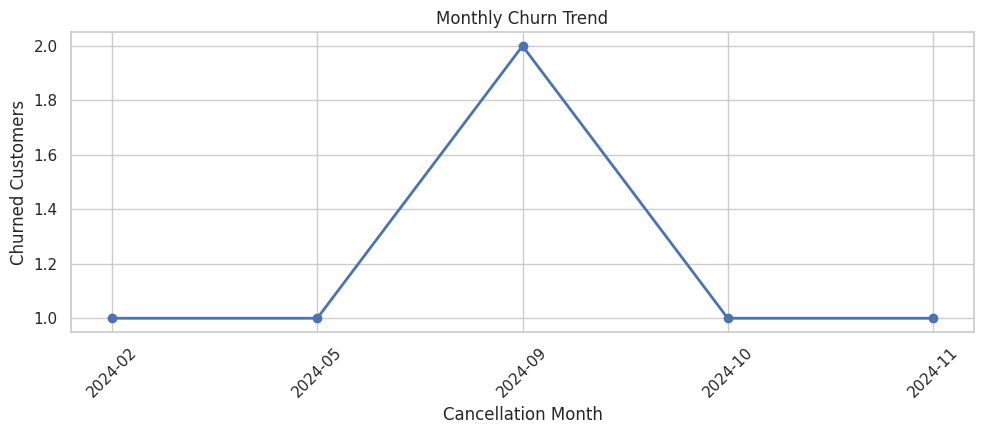

In [34]:
plt.figure(figsize=(10, 4.5))
plt.plot(
    monthly_churn["cancellation_month"].astype(str),
    monthly_churn["churned_customers"],
    marker="o",
    linewidth=2
)
plt.title("Monthly Churn Trend")
plt.xlabel("Cancellation Month")
plt.ylabel("Churned Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Tenure comparison
tenure_summary = (
    analysis.groupby("churn_flag")
    .agg(
        customers=("customerid", "nunique"),
        avg_tenure_days=("tenure_days", "mean"),
        median_tenure_days=("tenure_days", "median")
    )
    .rename(index={0: "Retained", 1: "Churned"})
)

tenure_summary

,customers,avg_tenure_days,median_tenure_days
churn_flag,,,
Retained,15,"1,588.07","1,491.00"
Churned,6,772.83,608.50


# 10. Why Are Customers Leaving?

Cancellation reasons provide the clearest direct evidence for the **why** dimension.

We evaluate both:
- number of churned customers,
- monthly-charge exposure,
- CLTV associated with the reason.

This prevents focusing only on the most common reason when another reason may have greater financial exposure.

In [36]:
reason_summary = (
    analysis.loc[analysis["churn_flag"] == 1]
    .groupby("cancellation_reason", dropna=False)
    .agg(
        churned_customers=("customerid", "nunique"),
        monthly_charges=("monthly_charges", "sum"),
        cltv=("cltv", "sum")
    )
    .assign(
        customer_share_pct=lambda x: x["churned_customers"] / churned_customers * 100,
        monthly_charge_share_pct=lambda x: x["monthly_charges"] / churned_mrr * 100
    )
    .sort_values("churned_customers", ascending=False)
)

reason_summary

,churned_customers,monthly_charges,cltv,customer_share_pct,monthly_charge_share_pct
cancellation_reason,,,,,
Switched to competitor,2,25.98,1310,33.33,35.14
Forgot to cancel trial,1,16.99,42,16.67,22.98
Not enough content,1,8.99,230,16.67,12.16
Poor streaming quality,1,7.99,270,16.67,10.81
Too expensive,1,13.99,195,16.67,18.92


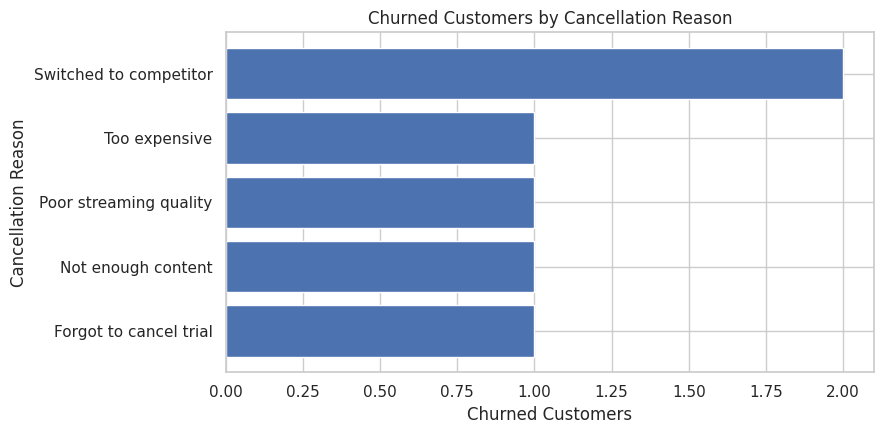

In [37]:
plt.figure(figsize=(9, 4.5))
plot_data = reason_summary.sort_values("churned_customers")
plt.barh(plot_data.index, plot_data["churned_customers"])
plt.title("Churned Customers by Cancellation Reason")
plt.xlabel("Churned Customers")
plt.ylabel("Cancellation Reason")
plt.tight_layout()
plt.show()

# 11. Support Intelligence: Complaints, Escalations & CSAT

The reference project emphasizes the relationship between support escalations and churn.

A customer-level view is more appropriate than simply comparing support-event rows because customers can generate multiple support records.

We therefore compare:
- customers with at least one escalation,
- customers without an escalation,
- churn rate,
- complaint volume,
- CSAT.

In [38]:
support_customer_summary = (
    analysis.assign(
        support_status=np.where(
            analysis["has_escalation"] == 1,
            "At least one escalation",
            "No escalation"
        )
    )
    .groupby("support_status")
    .agg(
        customers=("customerid", "nunique"),
        churned=("churn_flag", "sum"),
        churn_rate=("churn_flag", "mean"),
        avg_complaints=("complaint_count", "mean"),
        avg_csat=("avg_csat", "mean")
    )
    .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
    .drop(columns="churn_rate")
)

support_customer_summary

,customers,churned,avg_complaints,avg_csat,churn_rate_pct
support_status,,,,,
At least one escalation,5,5,1.40,32.00,100.00
No escalation,16,1,0.12,60.00,6.25


In [39]:
# Customer-level escalation/churn association
escalation_churn_table = pd.crosstab(
    analysis["has_escalation"],
    analysis["churn_flag"],
    margins=True
)

escalation_churn_table

churn_flag,0,1,All
has_escalation,,,
0,15,1,16
1,0,5,5
All,15,6,21


In [40]:
# Correlation is descriptive here, not causal.
support_corr = analysis[["has_escalation", "churn_flag"]].corr().iloc[0, 1]

print(f"Point-biserial/Pearson correlation between has_escalation and churn_flag: {support_corr:.2f}")
print("Interpretation: in this dataset, escalation presence is strongly associated with churn.")
print("Caution: n=21 and the timing of escalation relative to cancellation prevents a causal conclusion.")

Point-biserial/Pearson correlation between has_escalation and churn_flag: 0.88
Interpretation: in this dataset, escalation presence is strongly associated with churn.
Caution: n=21 and the timing of escalation relative to cancellation prevents a causal conclusion.


# 12. Churn-Risk Segmentation

The source database already contains `churn_score`, so we do not train a new predictive model here.

Instead, we translate the supplied score into:
- **Low:** < 50
- **Medium:** 50–69
- **High:** ≥ 70

This reproduces the risk-banding logic in the reference notebook.

**Important:** because `churn_score` is already present in the source data, this is a descriptive segmentation exercise—not evidence that we built and validated a predictive model.

In [41]:
risk_summary = (
    analysis.groupby("churn_risk", observed=False)
    .agg(
        customers=("customerid", "nunique"),
        churned=("churn_flag", "sum"),
        churn_rate=("churn_flag", "mean"),
        monthly_charges=("monthly_charges", "sum"),
        cltv=("cltv", "sum")
    )
    .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
    .drop(columns="churn_rate")
)

risk_summary

,customers,churned,monthly_charges,cltv,churn_rate_pct
churn_risk,,,,,
Low,13,0,286.87,14057,0.00
Medium,2,0,34.98,1190,0.00
High,6,6,73.94,2047,100.00


In [42]:
# High-risk customer detail
high_risk_customers = (
    analysis.loc[analysis["churn_risk"] == "High", [
        "customerid", "customer_name", "plan_type", "contract_type",
        "subscription_type", "monthly_charges", "cltv", "churn_score",
        "churn_flag", "cancellation_reason", "has_escalation"
    ]]
    .sort_values("churn_score", ascending=False)
)

high_risk_customers

,customerid,customer_name,plan_type,contract_type,subscription_type,monthly_charges,cltv,churn_score,churn_flag,cancellation_reason,has_escalation
18,0022-TCJCI,raghvendra,Basic,Monthly,Referral,16.99,42,99,1,Forgot to cancel trial,1
1,0003-MKNFE,raghav,Premium,Annual,Paid,12.99,1150,91,1,Switched to competitor,1
4,0013-EXCHZ,mira,Standard,Monthly,Referral,13.99,195,88,1,Too expensive,1
11,0017-IUDMW,rangadevi,Standard,Monthly,Referral,7.99,270,83,1,Poor streaming quality,1
6,0013-SMEOE,mina,Basic,Monthly,Referral,8.99,230,79,1,Not enough content,0
13,0019-EFAEP,raju,Basic,Monthly,Referral,12.99,160,76,1,Switched to competitor,1


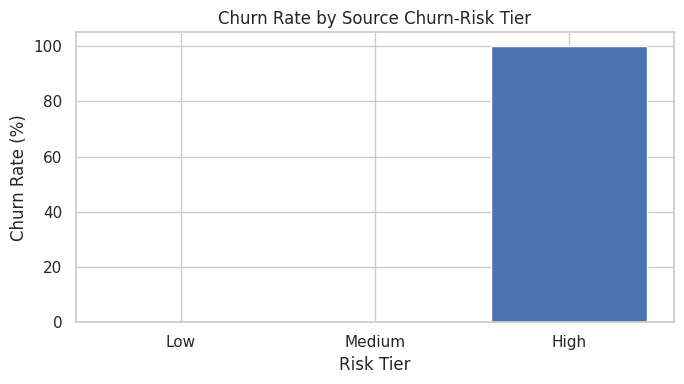

In [43]:
plt.figure(figsize=(7, 4))
risk_plot = risk_summary.reset_index()
plt.bar(risk_plot["churn_risk"].astype(str), risk_plot["churn_rate_pct"])
plt.title("Churn Rate by Source Churn-Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

# 13. Revenue & CLTV Impact

A churn analysis becomes more actionable when it quantifies financial exposure.

We calculate:
- total monthly charges,
- monthly charges tied to churned customers,
- share of monthly charges tied to churn,
- CLTV associated with churned customers,
- average CLTV for retained vs churned customers.

The reference report calls the churned monthly-charge amount "revenue loss" / "MRR leakage". Here it is labelled a **monthly-charge / MRR proxy** because the database does not provide an accounting ledger or realized post-cancellation revenue history.

In [44]:
financial_summary = pd.DataFrame({
    "Metric": [
        "Total monthly charges in customer base",
        "Monthly charges associated with churned customers",
        "Churned monthly-charge share",
        "Total CLTV in customer base",
        "CLTV associated with churned customers",
        "Average CLTV — retained",
        "Average CLTV — churned"
    ],
    "Value": [
        analysis["monthly_charges"].sum(),
        churned_mrr,
        revenue_at_risk_pct / 100,
        analysis["cltv"].sum(),
        cltv_lost,
        analysis.loc[analysis["churn_flag"] == 0, "cltv"].mean(),
        analysis.loc[analysis["churn_flag"] == 1, "cltv"].mean()
    ]
})

financial_summary

,Metric,Value
0,Total monthly charges in customer base,395.79
1,Monthly charges associated with churned customers,73.94
2,Churned monthly-charge share,0.19
3,Total CLTV in customer base,"17,294.00"
4,CLTV associated with churned customers,"2,047.00"
5,Average CLTV — retained,"1,016.47"
6,Average CLTV — churned,341.17


In [45]:
# Financial exposure by contract
contract_financial = (
    analysis.groupby("contract_type")
    .agg(
        customers=("customerid", "nunique"),
        churned=("churn_flag", "sum"),
        churn_rate=("churn_flag", "mean"),
        monthly_charges=("monthly_charges", "sum"),
        churned_monthly_charges=("monthly_charges", lambda s: s[analysis.loc[s.index, "churn_flag"].eq(1)].sum()),
        cltv=("cltv", "sum")
    )
    .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
    .drop(columns="churn_rate")
)

contract_financial

,customers,churned,monthly_charges,churned_monthly_charges,cltv,churn_rate_pct
contract_type,,,,,,
Annual,12,1,285.88,12.99,14517,8.33
Monthly,9,5,109.91,60.95,2777,55.56


# 14. Retention Prioritization View

For operational use, combine:
- churn score,
- contract type,
- plan,
- monthly charges,
- CLTV,
- support escalation,
- cancellation reason.

For already-churned customers, this helps explain the lost-value cohort.

For active customers, the same framework can be used as a **retention queue** if the source churn score is a genuinely forward-looking risk score.

In [46]:
# Active-customer prioritization queue
active_priority = (
    analysis.loc[analysis["churn_flag"] == 0, [
        "customerid", "customer_name", "plan_type", "contract_type",
        "subscription_type", "monthly_charges", "cltv", "churn_score",
        "churn_risk", "complaint_count", "escalation_count", "has_escalation",
        "avg_csat"
    ]]
    .sort_values(
        ["churn_score", "cltv", "monthly_charges"],
        ascending=[False, False, False]
    )
)

active_priority

,customerid,customer_name,plan_type,contract_type,subscription_type,monthly_charges,cltv,churn_score,churn_risk,complaint_count,escalation_count,has_escalation,avg_csat
16,0020-JDNXP,rikim,Premium,Annual,Organic,20.99,550,62,Medium,0.00,0.00,0,NaN
15,0020-INWCK,parvati,Standard,Monthly,Organic,13.99,640,58,Medium,0.00,0.00,0,NaN
20,0023-UYUPN,sudevi,Standard,Monthly,Paid,13.99,790,47,Low,0.00,0.00,0,NaN
9,0016-QLJIS,arjun,Basic,Annual,Organic,6.99,335,41,Low,0.00,0.00,0,NaN
8,0015-UOCOJ,maya,Standard,Monthly,Organic,13.99,240,34,Low,0.00,0.00,0,NaN
2,0004-TLHLJ,lalita,Basic,Monthly,Organic,6.99,210,34,Low,0.00,0.00,0,NaN
17,0021-IKXGC,vishakha,Standard,Annual,Paid,13.99,840,27,Low,0.00,0.00,0,NaN
5,0013-MHZWF,durga,Standard,Annual,Paid,17.99,720,22,Low,1.00,0.00,0,90.00
12,0018-NYROU,chitra,Standard,Annual,Organic,13.99,980,19,Low,0.00,0.00,0,NaN
10,0017-DINOC,shiva,Premium,Annual,Organic,22.99,1610,14,Low,0.00,0.00,0,NaN


### Practical retention logic

A business retention queue can be structured as:

1. **High churn score + high CLTV** → immediate outreach
2. **High churn score + support escalation** → service recovery first
3. **Monthly contract + elevated churn score** → test annual-plan migration
4. **Repeated complaints / low CSAT** → root-cause resolution
5. **Content dissatisfaction** → targeted content/engagement intervention
6. **Competitor switching** → competitive pricing/content/value investigation

These are operational hypotheses derived from the observed fields; they are not proof that any single intervention will reduce churn.

# 15. Relationship Analysis

The original project demonstrates correlation analysis with encoded categorical variables.

For this replication, we avoid assigning arbitrary numeric codes to nominal categories such as plan or acquisition source because those codes can create misleading correlations.

Instead, we use genuinely numeric/binary variables for the correlation matrix.

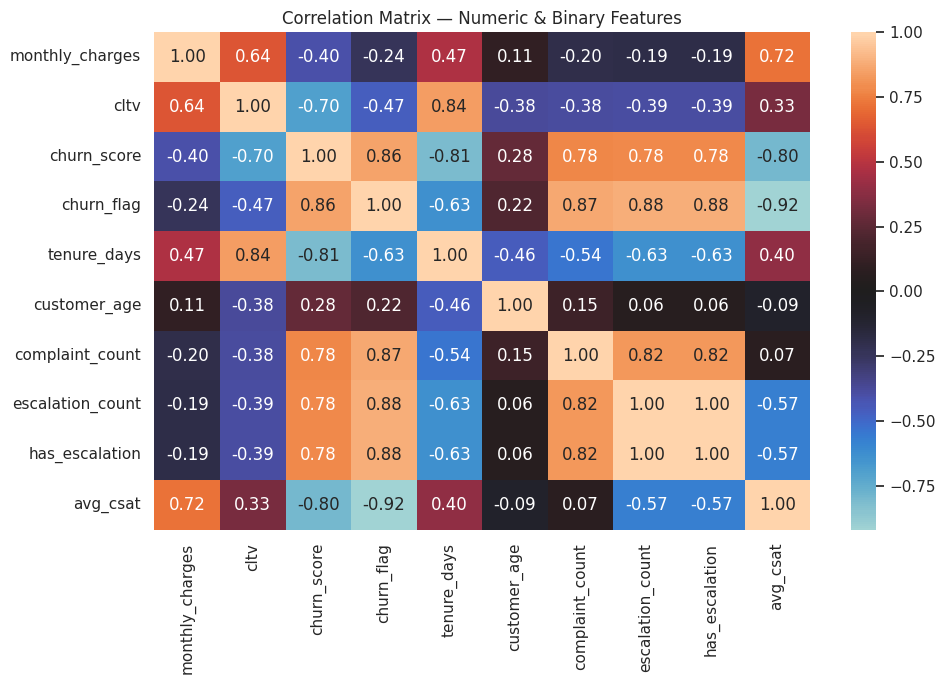

In [47]:
numeric_features = [
    "monthly_charges",
    "cltv",
    "churn_score",
    "churn_flag",
    "tenure_days",
    "customer_age",
    "complaint_count",
    "escalation_count",
    "has_escalation",
    "avg_csat"
]

corr_matrix = analysis[numeric_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix — Numeric & Binary Features")
plt.tight_layout()
plt.show()

# 16. Executive Visuals

These visuals are designed to be reusable in a presentation or portfolio case study.

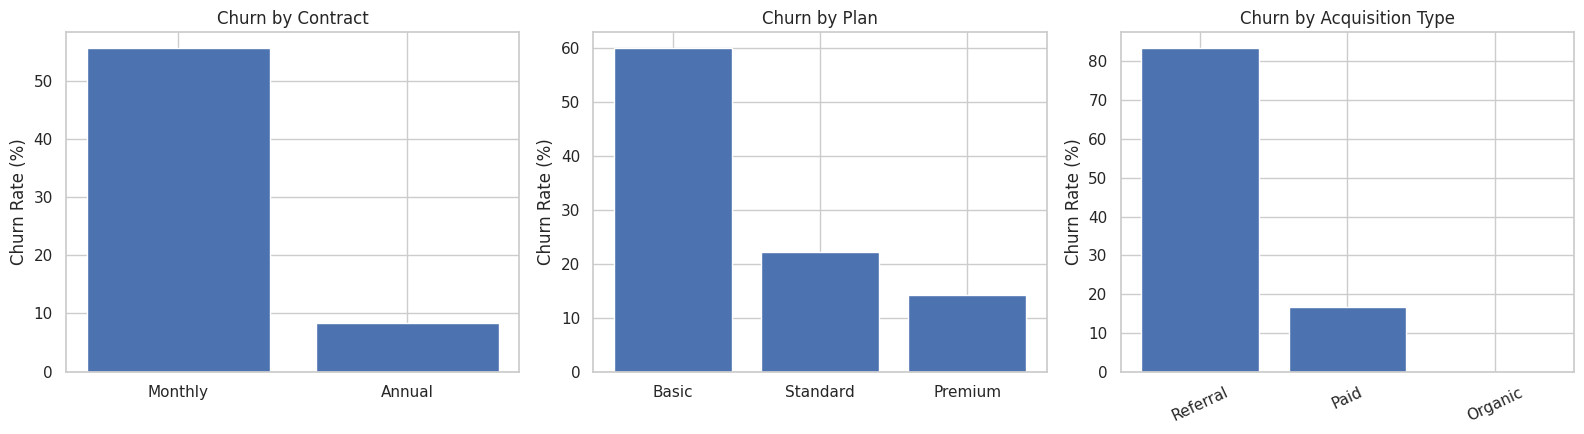

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Contract
contract_plot = contract_summary.reset_index()
axes[0].bar(contract_plot["contract_type"], contract_plot["churn_rate_pct"])
axes[0].set_title("Churn by Contract")
axes[0].set_ylabel("Churn Rate (%)")

# Plan
plan_plot = plan_summary.reset_index()
axes[1].bar(plan_plot["plan_type"], plan_plot["churn_rate_pct"])
axes[1].set_title("Churn by Plan")
axes[1].set_ylabel("Churn Rate (%)")

# Acquisition
acq_plot = acquisition_summary.reset_index()
axes[2].bar(acq_plot["subscription_type"], acq_plot["churn_rate_pct"])
axes[2].set_title("Churn by Acquisition Type")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

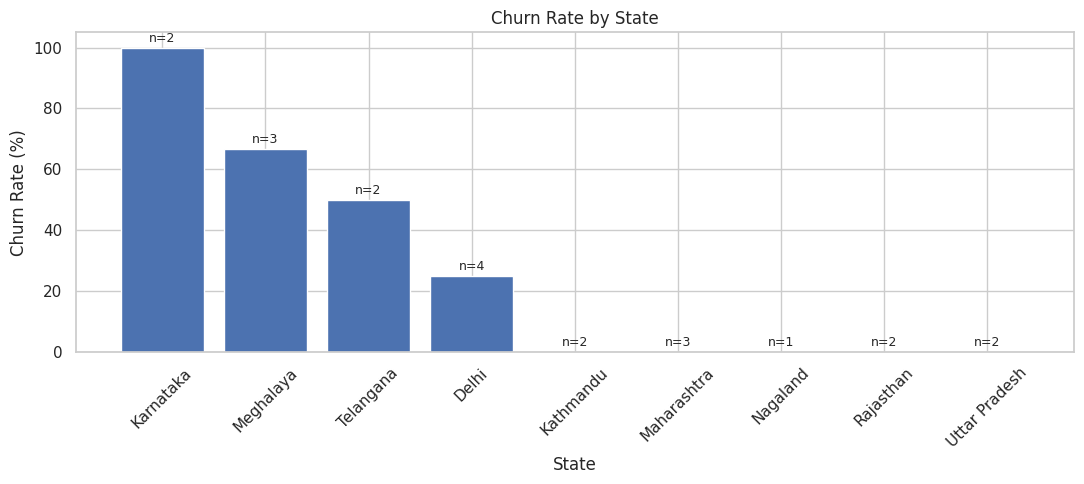

In [49]:
# Churn rate by state with customer counts annotated
state_plot = (
    analysis.groupby("state")
    .agg(customers=("customerid", "nunique"), churn_rate=("churn_flag", "mean"))
    .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
    .sort_values("churn_rate_pct", ascending=False)
)

plt.figure(figsize=(11, 5))
bars = plt.bar(state_plot.index, state_plot["churn_rate_pct"])

for bar, n in zip(bars, state_plot["customers"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"n={n}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Churn Rate by State")
plt.xlabel("State")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 17. SQL-in-Python Analysis Examples

Because the project is explicitly a SQL + Python workflow, we also reproduce key analyses directly in SQL.

This is useful in interviews because it demonstrates that the analyst can:
- inspect relational data,
- aggregate before joining,
- calculate business KPIs in SQL,
- then move the result into pandas for visualization and deeper analysis.

In [50]:
conn = sqlite3.connect(DB_PATH)

sql_contract_churn = """
SELECT
    contract_type,
    COUNT(DISTINCT customerid) AS customers,
    SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END) AS churned,
    ROUND(
        100.0 * SUM(CASE WHEN cancellation_date IS NOT NULL THEN 1 ELSE 0 END)
        / COUNT(DISTINCT customerid), 2
    ) AS churn_rate_pct
FROM db_subscription
GROUP BY contract_type
ORDER BY churn_rate_pct DESC;
"""

sql_contract_result = pd.read_sql_query(sql_contract_churn, conn)
sql_contract_result

,contract_type,customers,churned,churn_rate_pct
0,Monthly,9,5,55.56
1,Annual,12,1,8.33


In [51]:
sql_reason_churn = """
SELECT
    cancellation_reason,
    COUNT(*) AS churned_customers,
    ROUND(SUM(monthly_charges), 2) AS monthly_charges,
    SUM(cltv) AS cltv
FROM db_subscription
WHERE cancellation_date IS NOT NULL
GROUP BY cancellation_reason
ORDER BY churned_customers DESC, monthly_charges DESC;
"""

sql_reason_result = pd.read_sql_query(sql_reason_churn, conn)
sql_reason_result

,cancellation_reason,churned_customers,monthly_charges,cltv
0,Switched to competitor,2,25.98,1310
1,Forgot to cancel trial,1,16.99,42
2,Too expensive,1,13.99,195
3,Not enough content,1,8.99,230
4,Poor streaming quality,1,7.99,270


In [52]:
# SQL support aggregation before joining to subscription data
sql_support_join = """
WITH support_customer AS (
    SELECT
        customerid,
        COUNT(*) AS complaint_count,
        SUM(CASE WHEN escalations = 'Y' THEN 1 ELSE 0 END) AS escalation_count,
        MAX(CASE WHEN escalations = 'Y' THEN 1 ELSE 0 END) AS has_escalation,
        AVG(csat_score) AS avg_csat
    FROM db_support
    GROUP BY customerid
)
SELECT
    CASE
        WHEN s.cancellation_date IS NOT NULL THEN 'Churned'
        ELSE 'Retained'
    END AS customer_status,
    COALESCE(sc.has_escalation, 0) AS has_escalation,
    COUNT(*) AS customers
FROM db_subscription s
LEFT JOIN support_customer sc
    ON s.customerid = sc.customerid
GROUP BY customer_status, has_escalation
ORDER BY customer_status, has_escalation;
"""

sql_support_result = pd.read_sql_query(sql_support_join, conn)
sql_support_result

,customer_status,has_escalation,customers
0,Churned,0,1
1,Churned,1,5
2,Retained,0,14
3,Retained,0,1


# 18. Executive Summary

## What the data says

### 1. Overall churn
The customer base contains **21 customers**, of whom **6 have churned**, producing a **28.57% churn rate** and **71.43% retention rate**.

### 2. Contract structure is the strongest segment signal
Monthly-contract churn is **55.56%**, versus **8.33%** for annual contracts — an absolute gap of **47.22 percentage points** and a **6.67× rate ratio**.

### 3. Plan-level risk is concentrated in Basic
Basic churn is **60%**, compared with **22.22%** for Standard and **14.29%** for Premium.

### 4. Referral acquisition is highly exposed
Referral customers churn at **83.33%** in this sample, with 5 of the 6 referral customers churning. This deserves acquisition-quality investigation.

### 5. Churn creates measurable financial exposure
The six churned customers account for **73.94** in monthly charges, representing **18.68%** of total monthly charges in the dataset. Their associated CLTV totals **2,047**.

### 6. Support escalation is strongly associated with churn
Five customers have at least one escalation, and all five churned. Among customers without an escalation, 1 of 16 churned. This is a strong sample-level association, but not proof of causation.

### 7. Churn appears concentrated in the earlier lifecycle
Using a fixed 2025-12-31 cutoff for active-customer tenure, average tenure is materially lower among churned customers than retained customers. This suggests the business should examine onboarding, early-value realization and first-renewal experience.

### 8. September 2024 is the peak cancellation month
September 2024 records 2 of the 6 cancellations, the highest monthly count in this dataset.

## Business hypotheses to investigate

1. **Monthly → annual migration:** test whether an annual-plan offer improves retention among suitable monthly customers.
2. **Referral-channel quality:** investigate whether referral leads have weaker product fit or different expectations.
3. **Support recovery:** examine escalated cases for technical, billing and service-quality root causes.
4. **Basic-plan value proposition:** investigate price/value/content differences behind Basic-plan churn.
5. **Competitive pressure:** investigate competitor switching and whether price/content/service changes preceded those cancellations.
6. **Early-lifecycle retention:** examine the first 3–12 months for activation and engagement signals.

# 19. Recommended Action Framework

| Priority area | Evidence in this dataset | Business question | Suggested next step |
|---|---|---|---|
| Contract | Monthly churn 55.56% vs annual 8.33% | Why are monthly users leaving? | Test annual migration / retention offers |
| Acquisition | Referral churn 83.33% | Are referral customers lower-fit? | Audit referral source quality and expectations |
| Support | 5/5 escalated customers churned | Are service failures preceding churn? | Build support recovery workflow |
| Plan | Basic churn 60% | Is Basic value insufficient? | Review price, content and feature usage |
| Competition | Competitor switching appears as a cancellation reason | Why are customers choosing alternatives? | Competitive pricing/content analysis |
| Lifecycle | Churned tenure is lower than retained tenure | Is early lifecycle experience weak? | Analyze onboarding and first-renewal behavior |

## Interview-ready project story

> **Situation:** An OTT subscription business was experiencing customer churn and needed to understand who was leaving, why they were leaving, and when churn was occurring.
>
> **Task:** I built an end-to-end churn analytics pipeline by extracting three relational tables from SQLite, cleaning the data, aggregating customer support interactions, engineering churn and tenure features, and analyzing churn across contract, plan, acquisition, geography, support and customer value.
>
> **Action:** I calculated 20+ analytical metrics and built visualizations for churn trends, contract/plan segmentation, cancellation reasons, support escalation and revenue exposure. I also quantified the relationship between churn and monthly contracts, referral acquisition, support escalation and CLTV.
>
> **Result:** The analysis found a 28.57% overall churn rate, with monthly-contract churn at 55.56% versus 8.33% for annual contracts. Six churned customers represented 73.94 in monthly charges and 2,047 in associated CLTV. The analysis translated these findings into retention hypotheses around contract migration, referral quality, support recovery and Basic-plan value.

# 20. Limitations & Analytical Guardrails

This dataset is intentionally small and appears designed for a learning/portfolio project. Therefore:

1. **n = 21 customers.** Segment-level percentages can be unstable.
2. **Geographic results are especially sensitive to small counts.** Karnataka shows 100% churn, but that is 2 of 2 customers.
3. **Correlation is not causation.** The escalation/churn association may reflect reverse causality, where dissatisfied customers escalate shortly before cancellation.
4. **`churn_score` is supplied by the source.** We did not build, train, validate or calibrate a predictive model in this notebook.
5. **Revenue at risk is a monthly-charge proxy.** The database does not contain an accounting ledger or post-cancellation revenue realization.
6. **Tenure for active customers uses a fixed data cutoff.** This differs from the original notebook's dynamic `today()` approach but makes the analysis reproducible.
7. **No experiment data is available.** Recommendations such as annual-plan migration should ultimately be validated through controlled experiments.
8. **No engagement/usage data is present.** For an OTT business, viewing frequency, watch time, content consumption and session recency would materially improve churn diagnosis.

# 21. Export Clean Analysis Dataset

The final customer-level dataset is exported so it can be reused in Tableau, Power BI, Excel, or a downstream modeling notebook.

In [53]:
export_path = Path("/content/drive/My Drive/EDA Projects/Churn Analysis & Customer Intelligence/exported_churn_analysis_detailed.csv")
analysis.to_csv(export_path, index=False)

print("Exported:", export_path.resolve())
print("Rows:", len(analysis))
print("Columns:", len(analysis.columns))

Exported: /content/drive/My Drive/EDA Projects/Churn Analysis & Customer Intelligence/exported_churn_analysis_detailed.csv
Rows: 21
Columns: 29


# Project Complete

### Portfolio deliverables from this notebook

- SQLite → pandas extraction
- Data-quality audit
- Cleaning and standardization
- Customer-level support aggregation
- Feature engineering
- 20+ churn/customer metrics
- Contract, plan, acquisition and geographic segmentation
- Churn timing and tenure analysis
- Cancellation-reason analysis
- Support escalation / CSAT analysis
- Risk-tier analysis
- Revenue and CLTV exposure
- SQL-in-Python examples
- Executive recommendations
- Interview-ready project narrative
- Reusable cleaned CSV output

**Next logical extension:** build a predictive churn model using historical behavior/engagement features, then evaluate it with time-aware validation and business-oriented metrics such as recall at a fixed retention capacity, precision among top-risk customers, and expected CLTV saved.